# Direction of Gene Transcription and Replication Fork

May 3, 2024

**Goal:** Can we discern chromatin changes w.r.t to the direction of gene transcription and the replication fork?


In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
repl_timing_file = 'datasets/computed_mnase/all_repl_timing_deconvolved.csv'
repl_timing = pd.read_csv(repl_timing_file).set_index('orf_name')
print(len(repl_timing), " genes with replication profiles")

repl_timing.head()


5250  genes with replication profiles


,timing,H_index
orf_name,,
YAL067W-A,53.314585,196
YAL067C,52.304185,194
YAL064C-A,52.809385,195
YAL064W,51.798985,193
YAL063C-A,51.798985,193


In [5]:
from src.replication_deconvolution_solver import plot_chrom_repl_timing_from_data

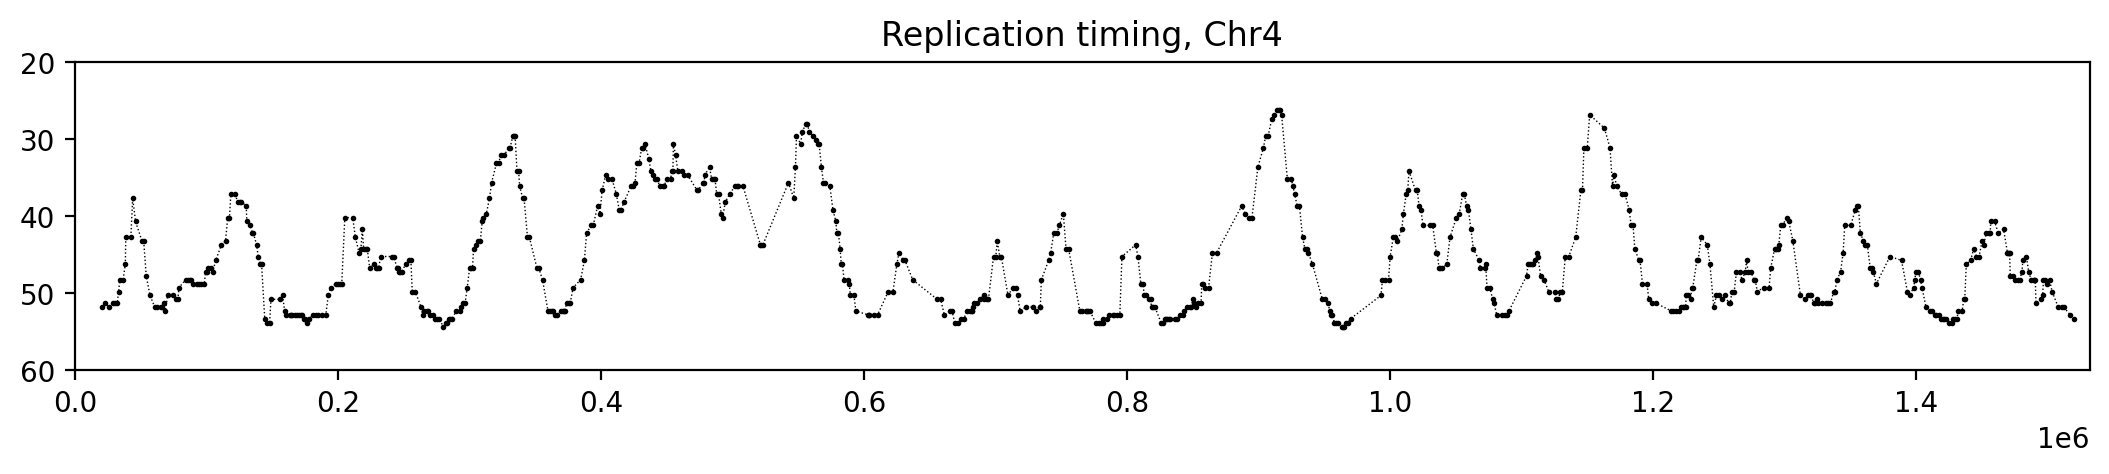

In [6]:
from src.geneset import get_deconvolved_geneset
geneset = get_deconvolved_geneset()

chrom = 4
plot_chrom_repl_timing_from_data(repl_timing, geneset, chrom)

In [7]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.173
1001/5574 - 00:00:08.227
2001/5574 - 00:00:15.039
3001/5574 - 00:00:21.508
4001/5574 - 00:00:28.332
5001/5574 - 00:00:34.981


In [8]:
promoter_analysis.correct_f_images_by_strand()

In [9]:
# Let's get the gene expression at the replication time.

from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()


# Which genes to start with?

Options:

Many genes, all genes compute the chromatin (some delta) before and after replication
- Prior-replication fork
- Post-replication fork

Early vs Late
High vs Low Gene expression


In [10]:
from src.gene_chromatin_replication_analysis import GeneChromatinReplicationAnalysis

gene_chrom_repl_analysis = GeneChromatinReplicationAnalysis(promoter_analysis,
                                                            ge_analysis,
                                                            repl_timing)

5232 genes with replication timing
Shape of the f images:  (5232, 227, 8, 25)


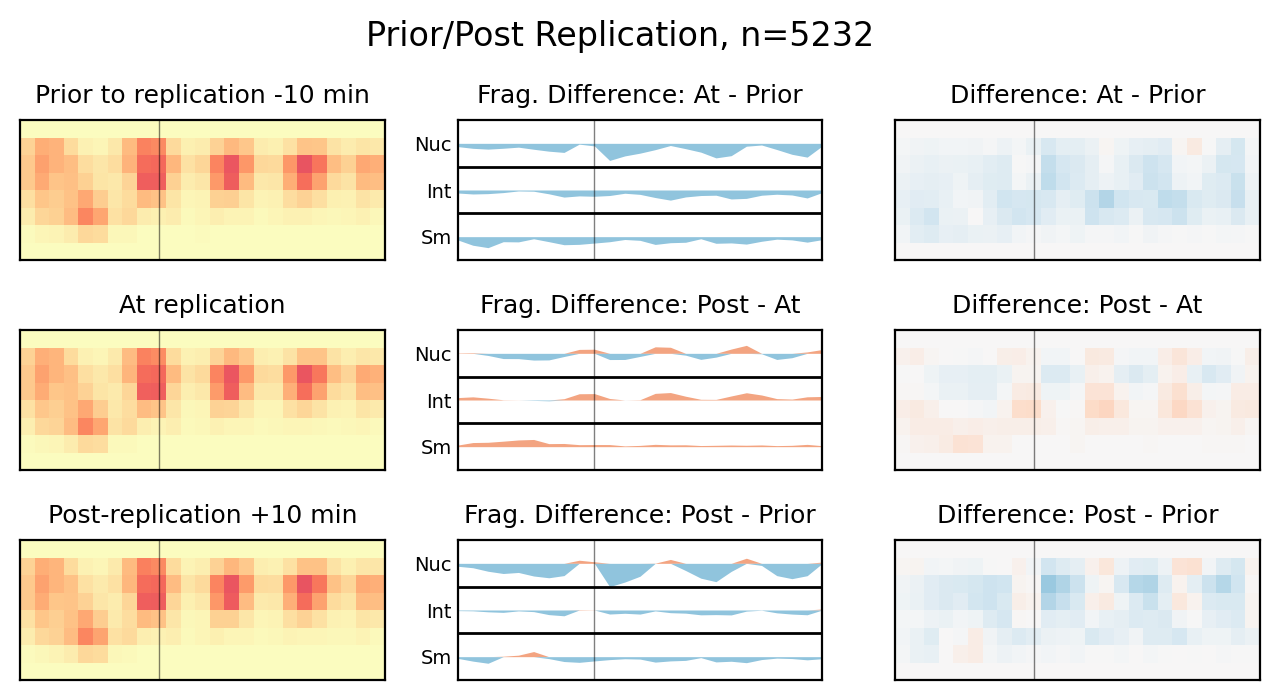

In [11]:
delta_ind = 20

gene_chrom_repl_analysis.select_subset(delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images()

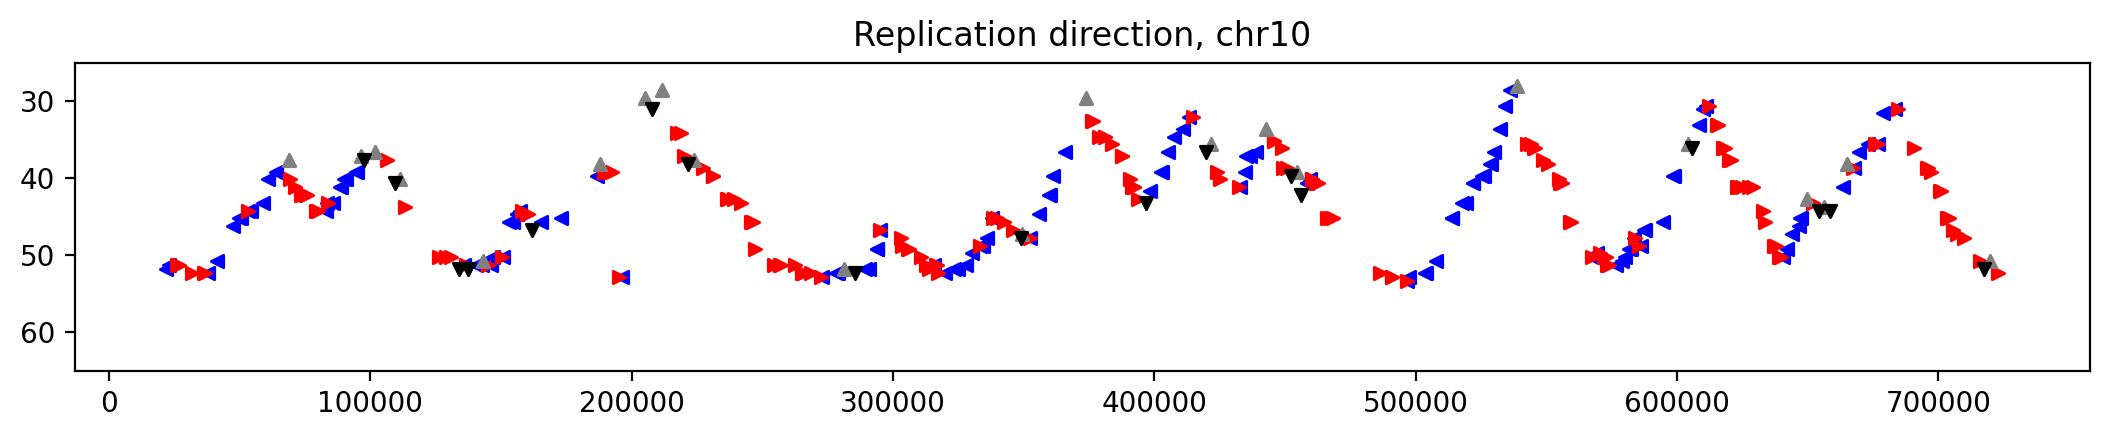

In [12]:
gene_chrom_repl_analysis.plot_replication_direction(10)

0

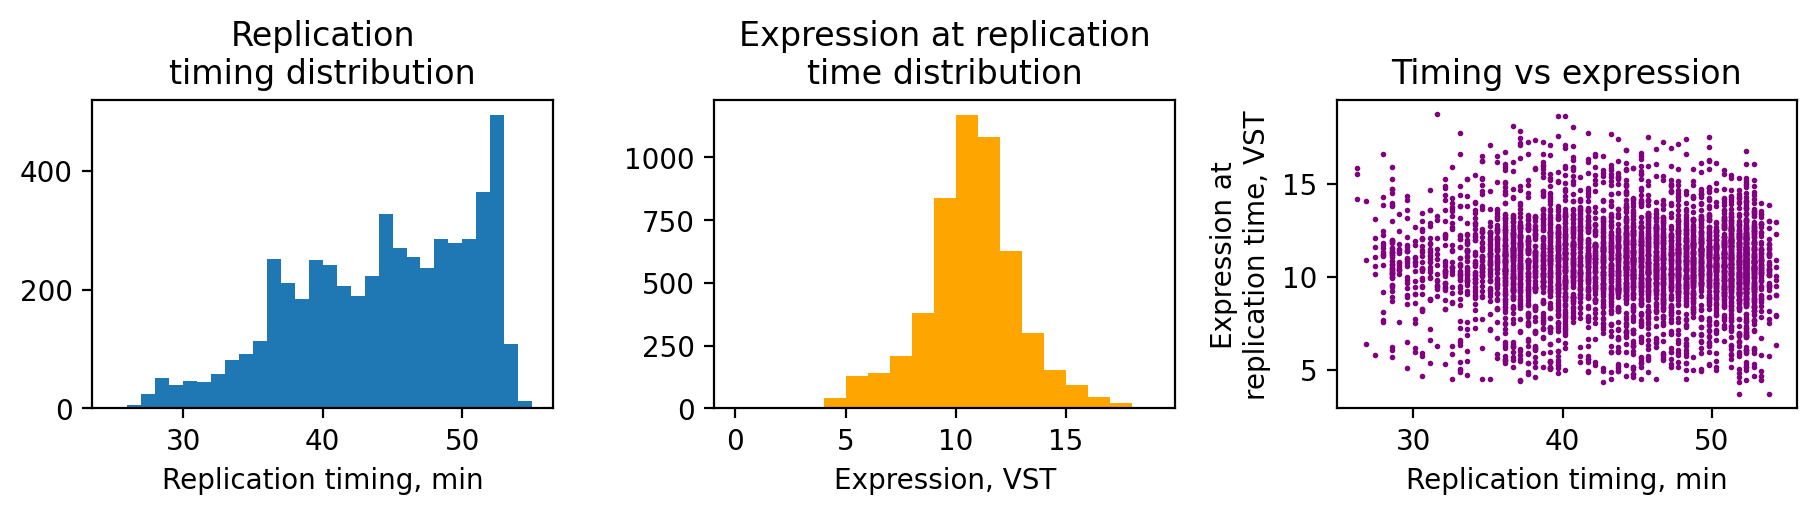

In [13]:
geneset_repl = gene_chrom_repl_analysis.geneset_repl

plt.figure(figsize=(11, 2))
plt.subplots_adjust(wspace=0.35)

plt.subplot(1, 3, 1)
plt.hist(geneset_repl.replication_timing, bins=np.arange(25, 56))
plt.title("Replication\ntiming distribution")
plt.xlabel("Replication timing, min")

plt.subplot(1, 3, 2)
plt.hist(geneset_repl.expression_at_replication, bins=np.arange(0, 20), 
         color='orange')
plt.title("Expression at replication\ntime distribution")
plt.xlabel("Expression, VST")

plt.subplot(1, 3, 3)
plt.scatter(geneset_repl.replication_timing,
            geneset_repl.expression_at_replication, s=1, c='purple')

plt.xlabel("Replication timing, min")
plt.ylabel("Expression at\nreplication time, VST")
plt.title("Timing vs expression")
0

In [14]:
geneset_repl = gene_chrom_repl_analysis.geneset_repl

# Filter for highly expressed and late replicating
geneset_repl = geneset_repl[(geneset_repl.expression_at_replication > 12) & 
                            (geneset_repl.replication_timing > 0)]

watson_right = geneset_repl[(geneset_repl.replication_direction == 'right') &
                            (geneset_repl.strand == '+')]
watson_left = geneset_repl[(geneset_repl.replication_direction == 'left') &
                            (geneset_repl.strand == '+')]

crick_right = geneset_repl[(geneset_repl.replication_direction == 'right') &
                            (geneset_repl.strand == '-')]
crick_left = geneset_repl[(geneset_repl.replication_direction == 'left') &
                            (geneset_repl.strand == '-')]

watson_peak = geneset_repl[(geneset_repl.replication_direction == 'early_peak') &
                            (geneset_repl.strand == '+')]
watson_trough = geneset_repl[(geneset_repl.replication_direction == 'late_trough') &
                            (geneset_repl.strand == '+')]


In [19]:
geneset_repl.to_csv('output/geneset_replication_direction_calculation.csv')

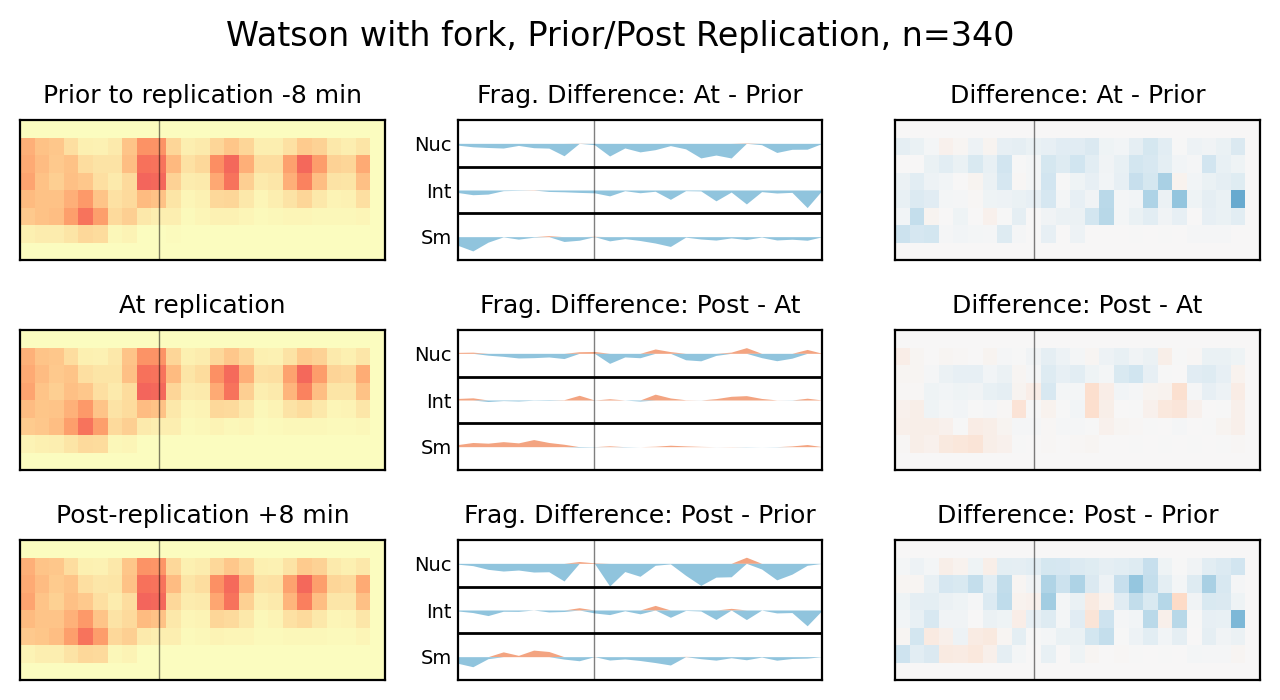

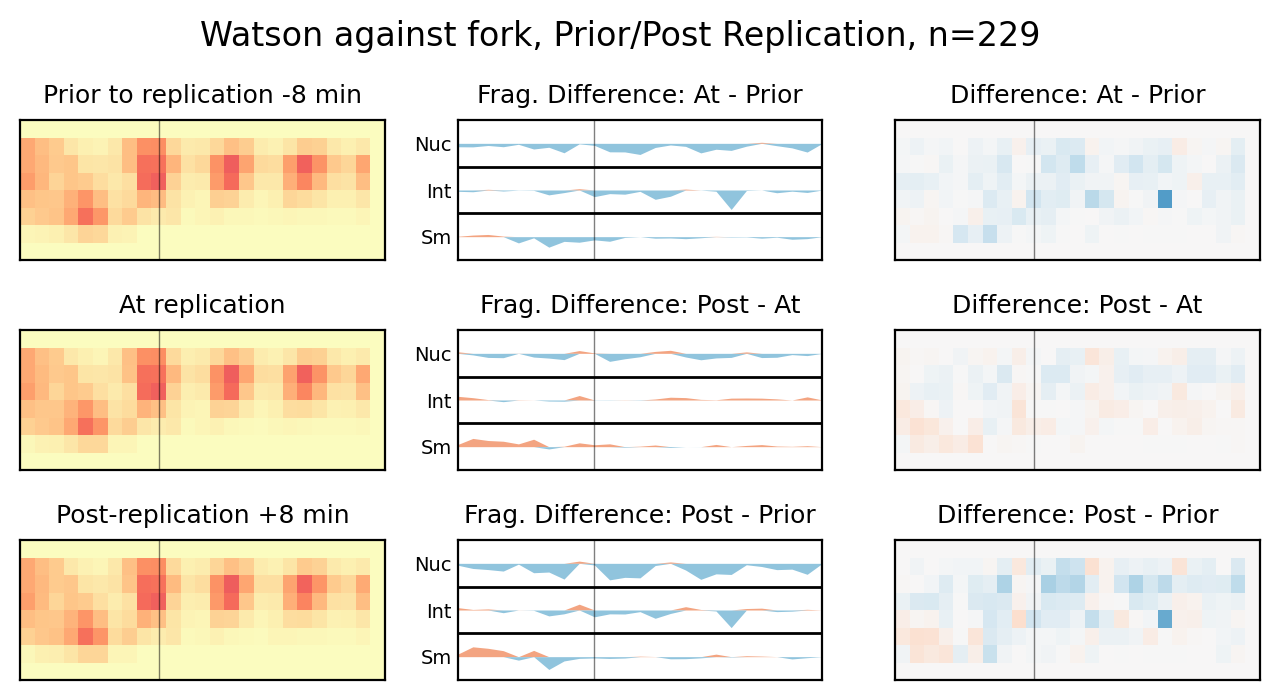

In [15]:
# Last analysis: Genes transcribing with replication vs against replication
# Hypothesis: Genes transcribing against replication will show more disruption in nucleosomes
# than with. And this will be more evident in highly expressed genes.
# Unsure if late/early will have an affect on this.
delta_ind = 15

gene_chrom_repl_analysis.select_subset(subset_orfs=watson_right.index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Watson with fork")

gene_chrom_repl_analysis.select_subset(subset_orfs=watson_left.index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Watson against fork")


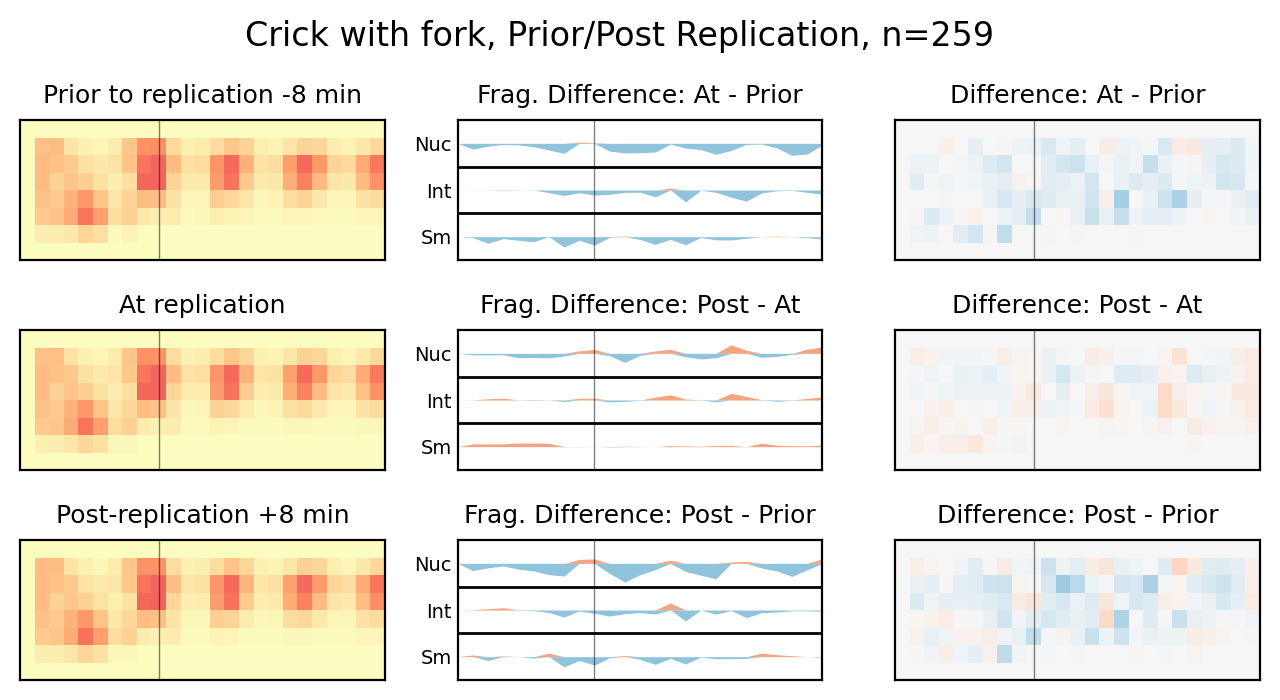

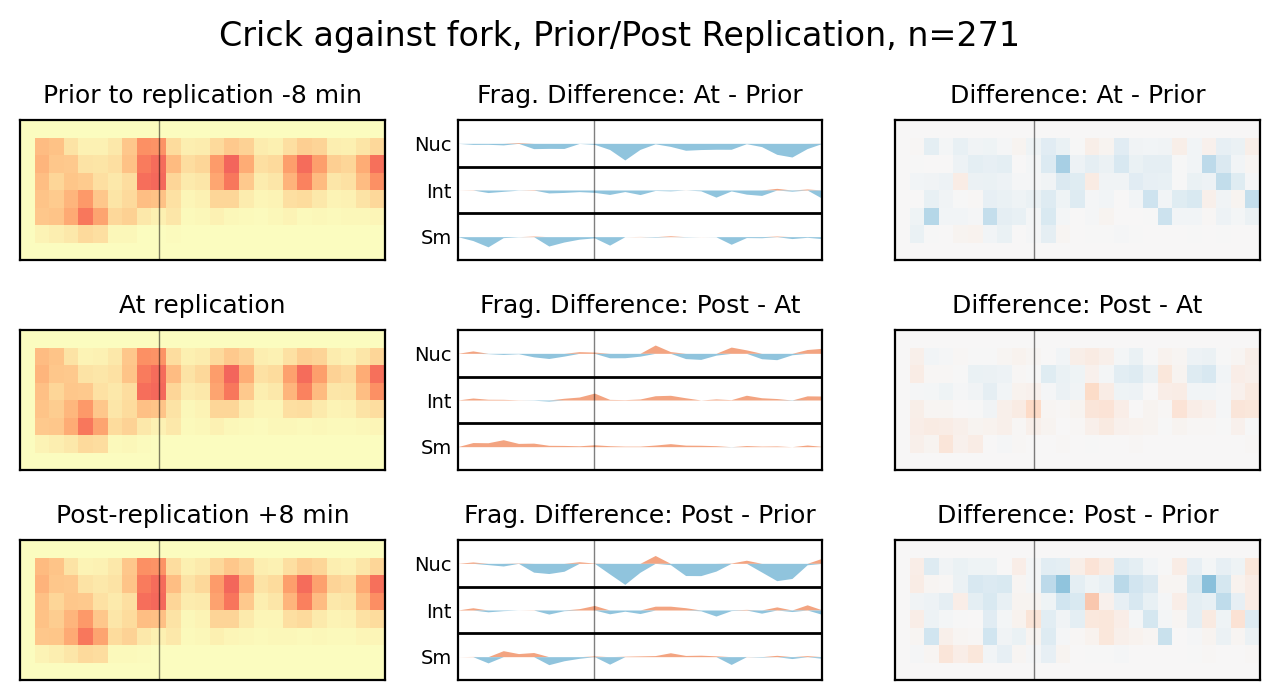

In [16]:
gene_chrom_repl_analysis.select_subset(subset_orfs=crick_left.index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Crick with fork")

gene_chrom_repl_analysis.select_subset(subset_orfs=crick_right.index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Crick against fork")

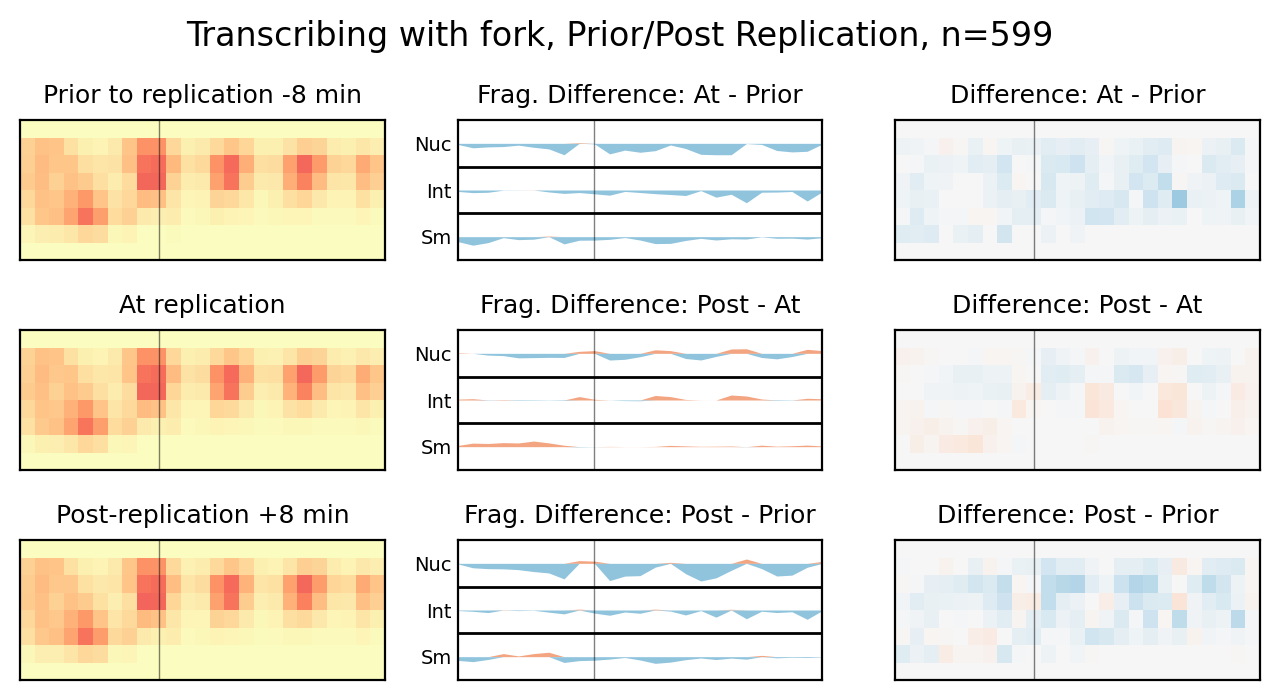

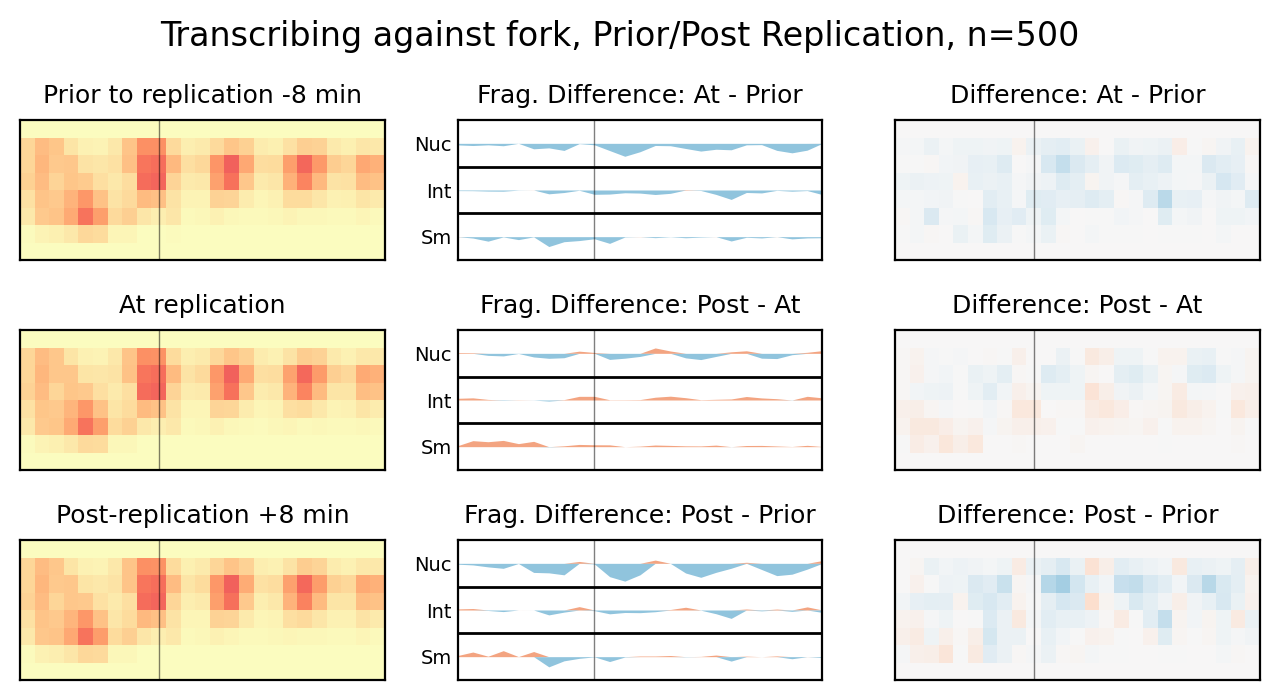

In [17]:

gene_chrom_repl_analysis.select_subset(subset_orfs=np.concatenate([crick_left.index,
                                                                   watson_right.index]), 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Transcribing with fork")

gene_chrom_repl_analysis.select_subset(subset_orfs=np.concatenate([crick_right.index,
                                                                  watson_left.index]), 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Transcribing against fork")